In [1]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [2]:
iris = load_iris()

In [3]:
# X = pd.DataFrame(iris.data)
# X.columns = iris.feature_names
X = iris.data
y = iris.target

<Axes: >

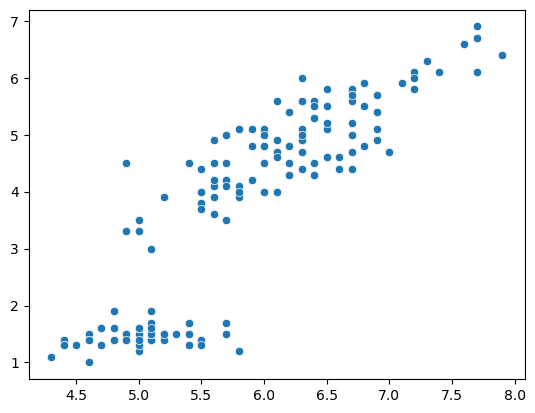

In [4]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,2])

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# Optional - dimensionality reduction using PCA

from sklearn.decomposition  import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)


In [16]:
# Elbow Method

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
    


<Axes: >

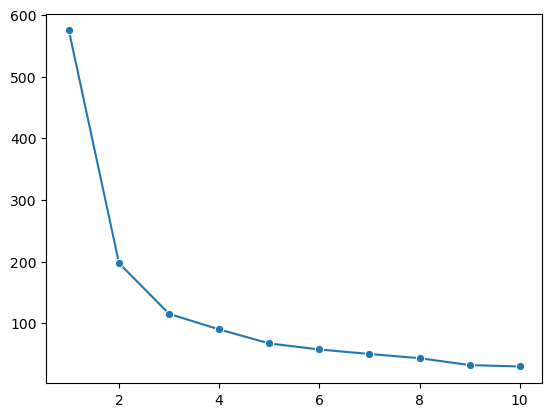

In [17]:
sns.lineplot(x=range(1, 11), y=wcss, marker='o')

<Axes: >

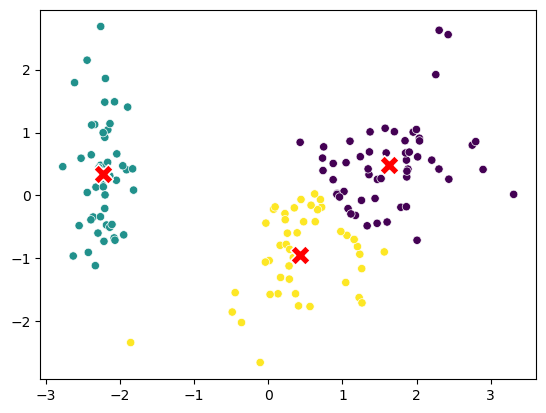

In [31]:
# KMeans

kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels)
# To visualize centroids
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="X", c="red", s=200)

<Axes: >

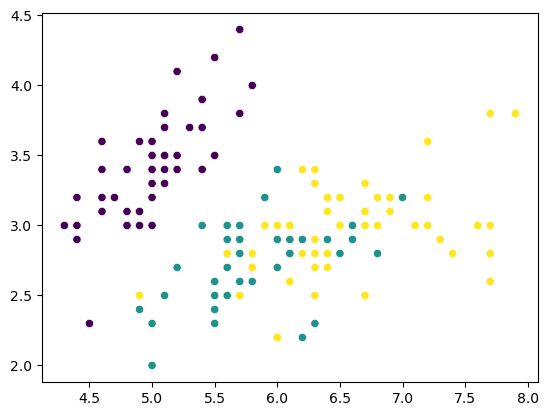

In [23]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c=y)